Lex Albrandt  
CS 440  
HW 3 writeup  
  

In [1]:
# Imports
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

# Part 1  
   
## 1)  
  
For the first question we model the joint distribution of pixel values using an autoregressive FVSBN. Using the chain rule of probability, the joint distribution  
is factorized as:  
   
$$p(x_1,x_2,\ldots,x_D)= \prod_{i=i}^{D} p(x_i \mid x_1,\ldots,x_{i-1})$$  
  
Where:  
- $x \in \{0,1\}^D$ is a binarized CIFAR-10 image
- $D=3072$ pixels
- Each pixel is modeled conditionally on previous pixels.  
  
Each conditional distribution is parameterized by a neural network and modeled as a Bernoulli distribution with sigmoid output:  
$$p(x_i=1 \mid x_{<i})=\sigma(f_{\theta}(x_{<i}))$$  
Where:  
- $f_{\theta}$ is the FVSBN network
- $\sigma(z)$ is the sigmoid function
  
Thus, the model outputs a probability between 0 and 1 for each pixel. During generation, pixels are sampled sequentially from left to right using the predicted  
Bernoulli probabilities.  
  
Masked Linear Layers are used to enforce the autoregressive constraint, ensuring the each pixel depends only on previously generated pixels, and not on future pixels.

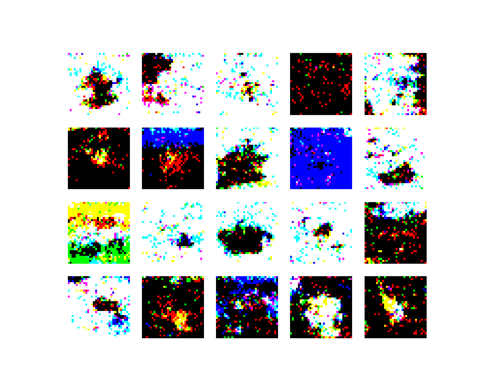

In [2]:
img = mpimg.imread("./figures/q1_imgs.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

We see in the output that the images are binary, sharp images with some edges and shapes emerging. The reason the images appear very sharp, but pixelated is because the  
model ouputs binary pixels (0 or 1) because of the Bernoulli sampling, and also because we binarized the CIFAR-10 images after loading the data.

## 2)  
  
In the second question of part 1 we train a variational auto-encoder (VAE) with the following properties:  
- Use CIFAR-10 for training/testing data  
- Use dimension 30 for both mean and variance  
  
The VAE learns a compressed representation of images in a 30-dimensional latent space. The architecture of the model is composed of the encoder, reparameterization,  
and decoder.  
  
### Encoder  
The encoder maps an image $x$ to a multivariate Gaussian distribution around a point in the latent space:   
$$q_{\theta}(z \mid x)=\mathcal{N}(\mu,{\sigma}^2)$$  
Where:  
- $\mu$ is the mean vector of the distribution 
- ${\sigma}^2$ is the logarithm of the variance of each dimension
  
The encoder takes an image and encodes it to two vectors that define the Gaussian distribution in the latent space.  
  
### Reparameterization Trick  
The reparameterization trick allows gradients to freely backpropogate through the layer. It is acheived using the following equation:  
$$z = \mu + \sigma \cdot \epsilon, \text{ }\epsilon \sim \mathcal{N}(0,1)$$
  
### Decoder  
The decoder maps the latent vectors back into an image space, and uses the Sigmoid activation function to ensure that all pixel values are in $[0,1]$
  
### Loss Function  
The loss function in the VAE is made up of two parts:  
- Reconstruction loss in the form of Binary cross-entropy, which measures how close the reconstructed image is to the original and  
- KL Divergence with $\beta$-VAE  
  
Here, the KL Divergence penalizes the network when the mean and log variance differ significantly from the Gaussian distribution. The   
$\beta$-VAE term weights the KL divergence, ensuring balanced reconstruction loss. Below are 10 images from each of the 10 classes in  
CIFAR-10.
  

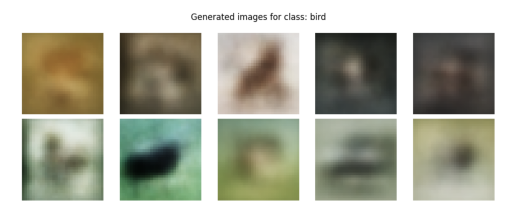

In [3]:
img = mpimg.imread("./figures/birds.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

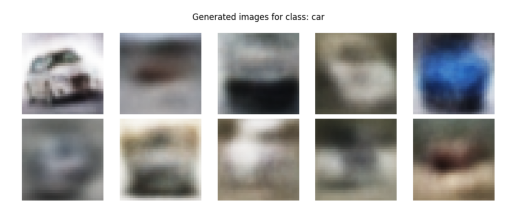

In [4]:
img = mpimg.imread("./figures/cars.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

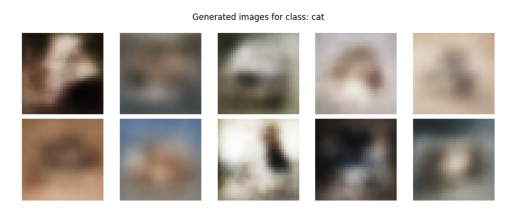

In [5]:
img = mpimg.imread("./figures/cats.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

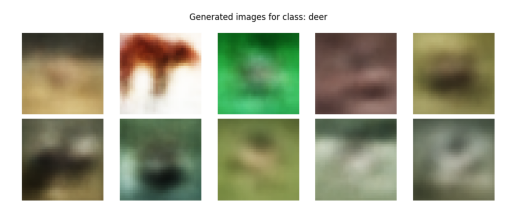

In [6]:
img = mpimg.imread("./figures/deer.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

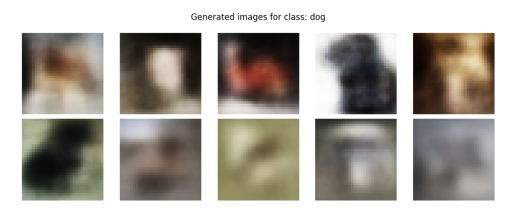

In [7]:
img = mpimg.imread("./figures/dogs.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

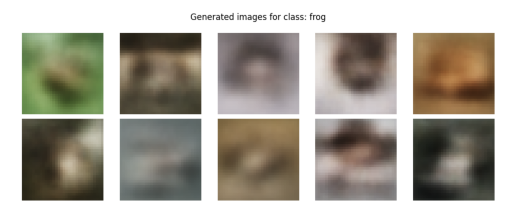

In [8]:
img = mpimg.imread("./figures/frogs.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

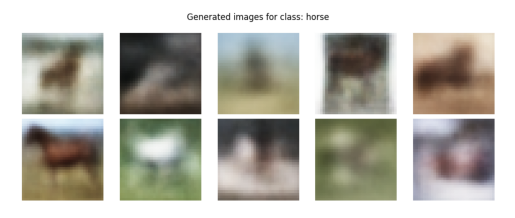

In [9]:
img = mpimg.imread("./figures/horses.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

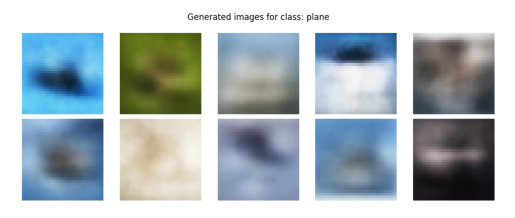

In [10]:
img = mpimg.imread("./figures/planes.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

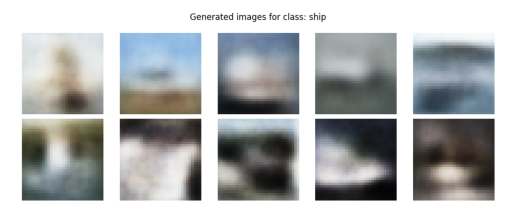

In [11]:
img = mpimg.imread("./figures/ships.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

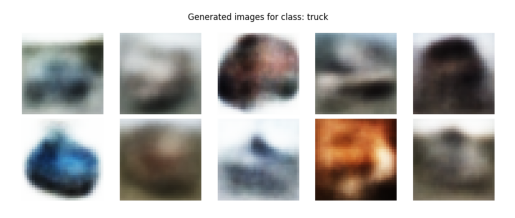

In [12]:
img = mpimg.imread("./figures/trucks.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

In each of the examples above we see that while the images have some recognizable shapes from each of the classes, the images themselves are blurry.  
This is because the VAE generates images based on a probability distribution in the latent space, which means it is sampling from a normal distribution  
which averages details, causing blurring. We also use pixel-wise loss in the binary cross-entropy loss function, which treats each pixel independetly,  
and averages the output if the model is uncertain of the pixel value. The binary cross-entropy also works in conjunction witht the KL divergence, which forces  
the latent space to look like a Gaussian distribution. Blurriness is also caused by a distinct compression from the original 3072 pixels  
in each image to 30 latent vectors, which causes the model to only store global structures, and lose sharp edges and fine textures.   
  

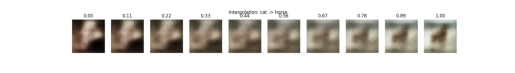

In [13]:
img = mpimg.imread("./figures/cat_horse.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.show()

In the image above we are interpolating between two latent vectors, in this case we have:  
$$z_A \text{ (cat), }z_B \text{ (horse)}$$  
We then create intermediate latent vectors at 10 different points between $A$ and $B$:  
$$z_{\alpha} = (1-{\alpha})z_A + {\alpha}z_B, \text{ } \alpha \in [0,1]$$  
In this case $\alpha$ is a number between 0 and 1 that determines how far we are away from point $A$, so:  
$$\alpha = 0 \text{: cat, } \alpha = 1 \text{: horse, } \alpha = 0.5 \text{: intermediate image}$$  
We then decode each $z_{\alpha}$, and obtain a smooth visual transition between the two images.  
  
## Part 2  
  
### 1)
For the first question of Part 2 we are using a pre-trained Resnet50 model. We start by modifiying the MNIST dataset that has the following properties for  
each image in the set:  
- Horizontal flip  
- $90^{\circ}$ rotation  
- Right translation by 5 pixels  
  
Below is a figure with 2 images from the original dataset and 2 images from the modified dataset:   
  

[]

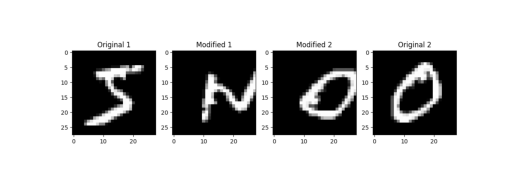

In [14]:
img = mpimg.imread("./figures/mnist_orig_mod.png")
plt.tight_layout()
plt.axis("off")
plt.imshow(img)
plt.plot()

The next section is the actual fine-tuning of the model. To acheive this we use a pretrained source model, ResNet50, and make a target model that copies the  
parameters and designs from the source model. Each of the weights and biases between layers are frozen, with the exception of the last hidden layer to the output  
layer. The model was then trained with 5 different training set sizes based on number of images per class:  
- 1 image per class = 10 total images  
- 5 images per class = 50 total images  
- 10 images per class = 100 total images
- 50 images per class = 500 total images  
- 100 images per class = 1000 total images  


[]

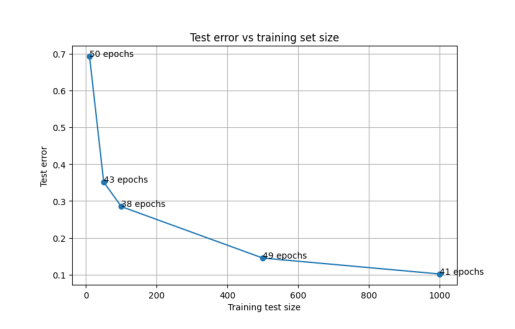

In [15]:
img = mpimg.imread("./figures/resnet50_mnist.png")
plt.axis("off")
plt.imshow(img)
plt.plot()

What we see in the plot above is as the training set size increases the test error and number of epochs to convergence also decreases. We see with larger training sets  
our gradient estimates are more stable, because the variance of SGD estimates is reduced, and overfitting is also reduced. Because the pre-trained model already knows  
generic features it was trained on, fine-tuning allows the model to reach convergence, and higher accuracy in far fewer epochs, making it very efficient. 
  
### 2)  
In the second part of part 2 we are asked to use the same pre-trained ResNet50 model, and considered the MNIST and FashionMNIT images. The goal of this model is to classify  
images as either a digit (MNIST) or clothing (FashionMNIST), thus we replaced the output layer with a layer of dimension 2 for binary classification. The output layer was  
then trained with 10 images from each MNIST and FashionMNIST. Below is a plot of test accuracy vs epochs.  

[]

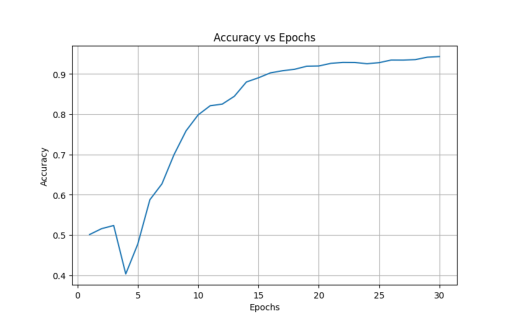

In [16]:
img = mpimg.imread("./figures/part2_2.png")
plt.axis("off")
plt.imshow(img)
plt.plot()

The accuracy acheived with this model was around 97% after 30 epochs. The accuracy of this model could be increased by increasing the training data, which would help  
the model generalize better. Accuracy could also be increased by fine-tuning more layers, applying transformation to the training data, and tuning of hyperparameters.  
  
The reason we see such high accuracy for a relatively small training data set is because of the properties leverage with fine-tuning. Because ResNet50 is already pre-trained  
the model has already learned generic visual features, which helps the model distinguish between digits and clothing. Additionally, because clothing and digits are very  
different visually, the output layer that was trained only needed minial training to correctly classify the images. 
  
## Part 3  
  
This section of the assigment was based on experimenting with a BERT transformer model. BERT was fine-tuned to answer questions using the SQUAD dataset.  
Each of the questions answered in this section have the following attributes:  
- Score: this is the model's confidence in its predicted answer. A score close to 1 indicates high confidence.  
- Start: this indicates the character index that the predicted answer begins at within the context.  
- End: this indicates the end character index of the predicted answer within the context.  
- Answer: this is the extracted text based on start and end indices.  
  
The model attempts to answer the question by extracting a span of raw text provided in the context. It does this by tokenizing the question and context and feeds them into  
the DistilBERT model, which then learns relationships between words in the question and words in the context through an attention mechanism and prediction heads.  
  
### Correct answer collection  
  

[]

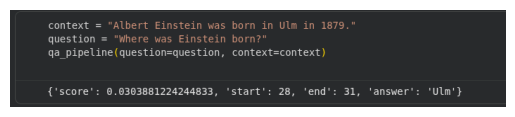

In [17]:
img = mpimg.imread("./figures/part3_corr1.png")
plt.axis("off")
plt.imshow(img)
plt.plot()

In the above example, the model correctly answers the question, but has a low confidence score, indicating that it is very unsure of the answer. However, the model also  
correctly indentifies the start and end points for the answer in the context. We can see in this example that the model extracts the answer directly from the source text.  
 

[]

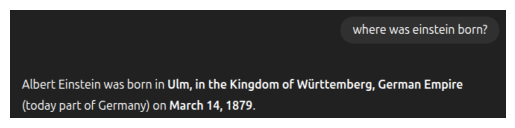

In [18]:
img = mpimg.imread("./figures/part3_corr_gpt1.png")
plt.axis("off")
plt.imshow(img)
plt.plot()

When we compare run the same question through ChatGPT, no context is provided, but GPT is not only able to answer the question correctly, but also provide additional  
information beyond what the BERT model can provide. This is because the BERT model is and extractiv question-answering model, where GPT is a generative pre-trained  
transformer, which allows it to synthesize and formulate answers that are not directly part of the source text.  
  

[]

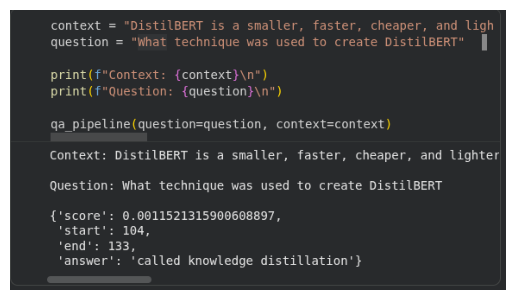

In [19]:
img = mpimg.imread("./figures/part3_corr2.png")
plt.axis("off")
plt.imshow(img)
plt.plot()

The context for the question in the above screenshot is: "DistilBERT is a smaller, faster, cheaper, and lighter version of BERT. It was created using a technique called  
knowledge distillation, where a smaller model learns to mimic the behavior of a larger teacher model while retaining most of its performance." This is a longer context  
than the previous example, and we see that the model is still not very confident in its final answer, but it essentially does answer the question correctly. Because the  
answer is provided within the context of the question, the model is able to extract the correct info from the context.  

[]

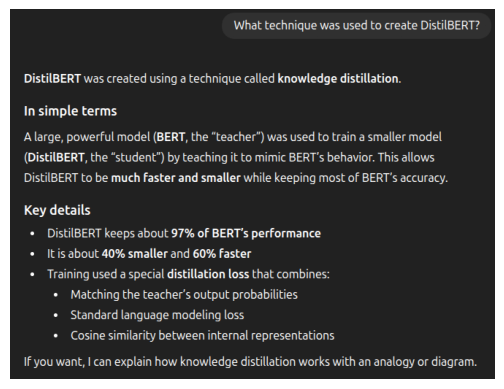

In [20]:
img = mpimg.imread("./figures/part3_corr_gpt2.png")
plt.axis("off")
plt.imshow(img)
plt.plot()

Once again, with GPT we see that no context is provided, but the model is able to generate the correct answer in addition to extra information related to the question  
itself.  
  
### Incorrect answer collection  
  

[]

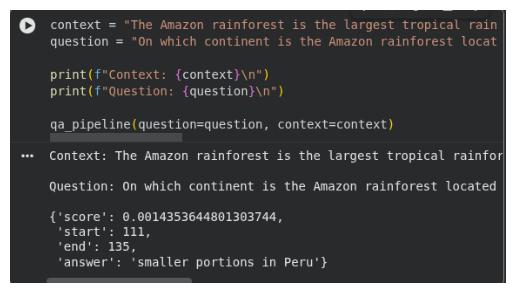

In [21]:
img = mpimg.imread("./figures/part3_incorr1.png")
plt.axis("off")
plt.imshow(img)
plt.plot()

The context for the above screenshot is: "The Amazon rainforest is the largest tropical rainforest in the world. It is located primarily in Brazil, with smaller portions  
in Peru, Colombia, and other South American countries." In this example, the context for the question does not provide the answer to the question, and we can see that the  
attempts to answer the question, but clearly fails. This is very common with extractive question-answer models because they do not perform well on inference questions. On  
the other hand, the screenshot below shows that GPT clearly has no problem answering the question without context. This is because GPT has world knowledge and reasoning   
capabilities, which alow it to infer answers, rather than extract text spans like DistilBERT.  
  

In [ ]:
img = mpimg.imread("./figures/part3_incorr_gpt1.png")
plt.axis("off")
plt.imshow(img)
plt.plot()

In [ ]:
img = mpimg.imread("./figures/part3_incorr2.png")
plt.axis("off")
plt.imshow(img)
plt.plot()

The context for the above screenshot is: "Isaac Newton developed the laws of motion and calculus. Albert Einstein developed the theory of relativity. Newton was born in England,  
while Einstein was born in Germany." The reason for the incorrect answer in this example is likely because of distractor confusion. The context named multiple people, with Isaac  
Newton appearing first. Multiple entities are mentioned in the context, and the QA model assigns a higher probability to earlier entities or spans that strongly correlate with  
common question patterns. GPT, on the other hand, correctly answered "Ulm, Germany" because it can maintain entity relationships across sentences and perrom reasoning.  